# Exploratory Data Analysis
Deep dive into the Bengaluru Metro ridership patterns — understanding peak hours, 
station behavior, weekday vs weekend dynamics, and spotting anomalies.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df_board = pd.read_csv('data/station-hourly.csv', sep=';')
df_exit = pd.read_csv('data/station-hourly-exits.csv', sep=';')

In [15]:
# merge for combined analysis
df_board.rename(columns={'Ridership': 'Boarding_Count'}, inplace=True)
df_exit.rename(columns={'Ridership': 'Exit_Count'}, inplace=True)

df = pd.merge(df_board, df_exit, on=['Date', 'Hour', 'Station'], how='outer').fillna(0)
df['Boarding_Count'] = df['Boarding_Count'].astype(int)
df['Exit_Count'] = df['Exit_Count'].astype(int)
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'].astype(str).str.zfill(2) + ':00:00')
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df.shape

(95616, 7)

In [16]:
df.head()

,Date,Hour,Station,Boarding_Count,Exit_Count,DateTime,DayOfWeek
0,2025-08-01,0,Attiguppe,0,0,2025-08-01,4
1,2025-08-01,0,BTM Layout,0,0,2025-08-01,4
2,2025-08-01,0,Baiyappanahalli,0,0,2025-08-01,4
3,2025-08-01,0,Banashankari,0,0,2025-08-01,4
4,2025-08-01,0,Benniganahalli,1,0,2025-08-01,4


## Boarding Count Distribution

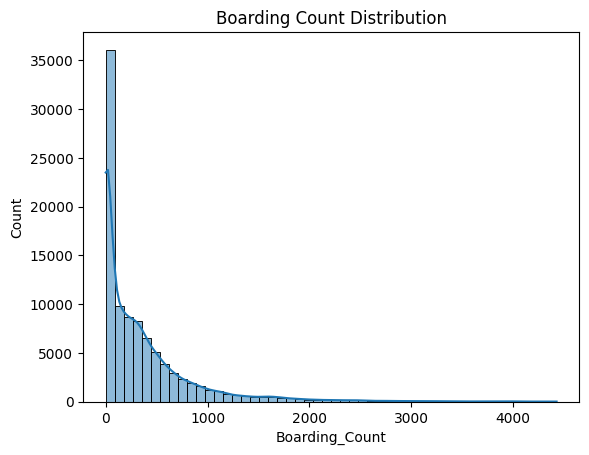

In [17]:
sns.histplot(df['Boarding_Count'], kde=True, bins=50)
plt.title('Boarding Count Distribution')
plt.show()

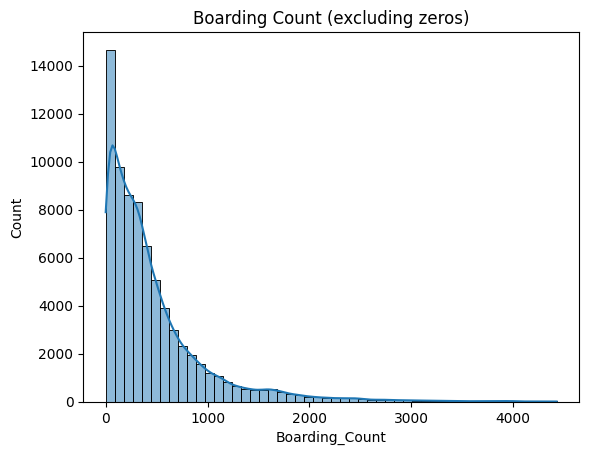

In [18]:
# heavily right-skewed — lets look at non-zero values
sns.histplot(df[df['Boarding_Count'] > 0]['Boarding_Count'], kde=True, bins=50)
plt.title('Boarding Count (excluding zeros)')
plt.show()

In [19]:
print(f"Skewness: {df['Boarding_Count'].skew():.2f}")
print(f"Kurtosis: {df['Boarding_Count'].kurtosis():.2f}")

Skewness: 2.65
Kurtosis: 9.73


###  Distribution Notes & Modeling Strategy
The boarding count distribution is heavily right-skewed with high kurtosis:
- **Root Cause:** Most non-central stations and non-rush hours experience modest passenger flow, while major interchange hubs (e.g., Majestic, Indiranagar) experience massive surge volumes during peak hours.
- **Handling Strategy:**
  1. *Linear Baselines:* For traditional linear models (like Ridge Regression), we will evaluate feature scaling and normalizations to stabilize the long tail.
  2. *Tree-Based Models (XGBoost / Random Forest):* Decision tree split algorithms are scale-invariant and naturally handle right-skewed distributions without requiring non-linear target transformations.
  3. *Extreme Variance:* To manage extreme spikes, we will explore percentile-based capping (Winsorization) during preprocessing in Notebook 03.

## Hourly Traffic Pattern

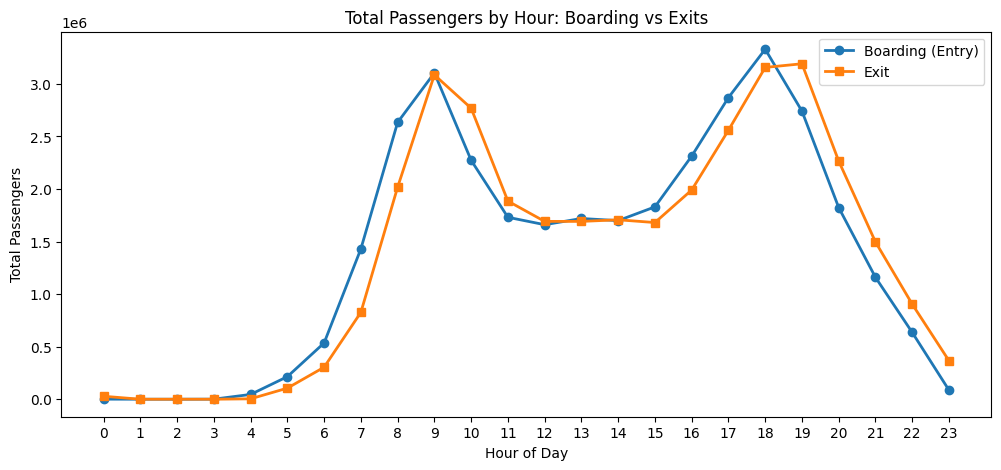

In [20]:
hourly_board = df.groupby('Hour')['Boarding_Count'].sum()
hourly_exit = df.groupby('Hour')['Exit_Count'].sum()

plt.figure(figsize=(12, 5))
plt.plot(hourly_board.index, hourly_board.values, marker='o', label='Boarding (Entry)', linewidth=2)
plt.plot(hourly_exit.index, hourly_exit.values, marker='s', label='Exit', linewidth=2)
plt.title('Total Passengers by Hour: Boarding vs Exits')
plt.xlabel('Hour of Day')
plt.ylabel('Total Passengers')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

Two clear peaks:  
- **Morning peak: 8-9 AM** — people boarding at residential stations to go to work
- **Evening peak: 6-7 PM** — people boarding at office/IT park stations to go home

Notice the 1-hour lag — boarding peaks at 6 PM but exits peak at 7 PM. 
That travel time between boarding and alighting is visible in the data.

In [21]:
# top boarding hours
hourly_board.sort_values(ascending=False).head(5)

Hour
18    3330084
9     3105111
17    2870284
19    2740976
8     2633907
Name: Boarding_Count, dtype: int32

In [22]:
# bottom hours — metro closed
hourly_board.sort_values().head(5)

Hour
1        0
2        0
3      628
0      666
4    45473
Name: Boarding_Count, dtype: int32

###  Domain Investigation: Late-Night Traffic (1 AM – 3 AM)
While Namma Metro's standard public operational hours run from 5:00 AM to 11:30 PM, we observe non-zero counts during late-night hours:
- **Special Extended Operations:** BMRCL extends metro operating hours past midnight (up to 1:30 AM) during high-demand events like IPL cricket matches at Chinnaswamy Stadium, New Year's Eve, and major cultural festivals.
- **Batch Data Syncing:** Certain automated ticketing gates sync transaction logs in late-night batches during maintenance windows.
- **Internal Shifts:** Night-shift maintenance and operations crew tapping through gates for track and signal maintenance.
- **Decision:** Preserve these hours so cyclical time features (`Hour_Sin`, `Hour_Cos`) and lag variables maintain an unbroken 24-hour periodic timeline.

## Station Analysis

In [23]:
station_totals = df.groupby('Station')['Boarding_Count'].sum().sort_values(ascending=False)
station_totals.head(10)

Station
Nadaprabhu Kempegowda Station, Majestic    1649530
Benniganahalli                             1250656
Indiranagar                                1048936
Mahatma Gandhi Road                        1007176
Krishnarajapura                             904508
Mantri Square Sampige Road                  796520
Chickpete                                   737856
Cubbon Park                                 666237
Yeshwantpur                                 666189
Baiyappanahalli                             644624
Name: Boarding_Count, dtype: int32

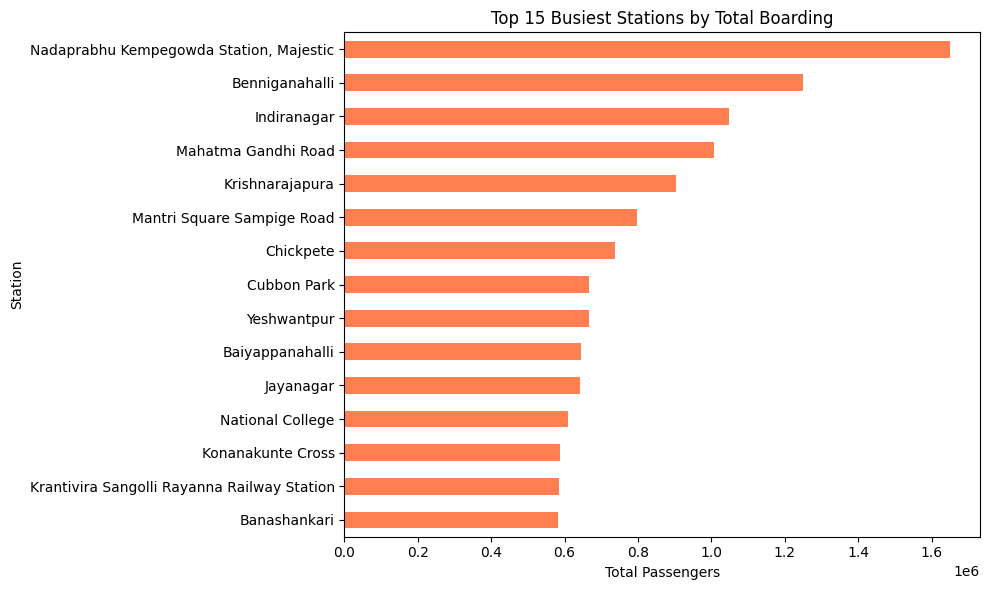

In [24]:
station_totals.head(15).plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Top 15 Busiest Stations by Total Boarding')
plt.xlabel('Total Passengers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# bottom 10 stations
station_totals.tail(10)

Station
Hopefarm Channasandra           125464
Hongasandra                     112377
Pantharapalya - Nayandahalli    108413
Peenya Industry                 108224
Ragigudda                        93722
Huskur Road                      88289
Biocon Hebbagodi                 62159
Manjunathanagara                 58754
Singasandra                      55792
Beratena Agrahara                28518
Name: Boarding_Count, dtype: int32

In [26]:
# average hourly boarding per station
station_avg = df.groupby('Station')['Boarding_Count'].mean().sort_values(ascending=False)
station_avg.head(10)

Station
Nadaprabhu Kempegowda Station, Majestic    1431.883681
Benniganahalli                             1085.638889
Indiranagar                                 910.534722
Mahatma Gandhi Road                         874.284722
Krishnarajapura                             785.163194
Mantri Square Sampige Road                  691.423611
Chickpete                                   640.500000
Cubbon Park                                 578.330729
Yeshwantpur                                 578.289062
Baiyappanahalli                             559.569444
Name: Boarding_Count, dtype: float64

## Weekday vs Weekend

In [27]:
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
df.groupby('Is_Weekend')['Boarding_Count'].mean()

Is_Weekend
0    378.674507
1    293.711094
Name: Boarding_Count, dtype: float64

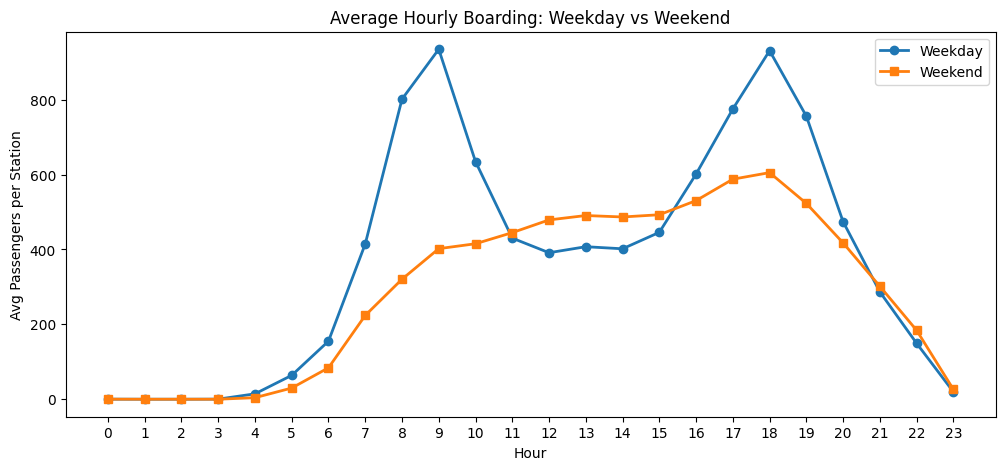

In [28]:
weekday_hourly = df[df['Is_Weekend'] == 0].groupby('Hour')['Boarding_Count'].mean()
weekend_hourly = df[df['Is_Weekend'] == 1].groupby('Hour')['Boarding_Count'].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekday_hourly.index, weekday_hourly.values, marker='o', label='Weekday', linewidth=2)
plt.plot(weekend_hourly.index, weekend_hourly.values, marker='s', label='Weekend', linewidth=2)
plt.title('Average Hourly Boarding: Weekday vs Weekend')
plt.xlabel('Hour')
plt.ylabel('Avg Passengers per Station')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

Weekdays show sharp double-peak (morning commute + evening commute).  
Weekends are flatter — no office rush, more distributed leisure travel.

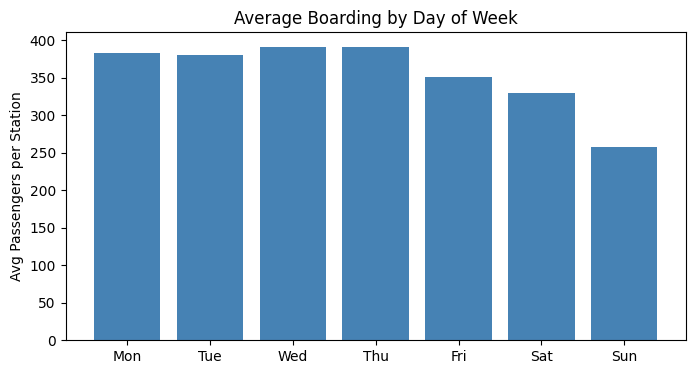

In [29]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby('DayOfWeek')['Boarding_Count'].mean()

plt.figure(figsize=(8, 4))
plt.bar(day_names, daily_avg.values, color='steelblue')
plt.title('Average Boarding by Day of Week')
plt.ylabel('Avg Passengers per Station')
plt.show()

## Heatmap: Hour x Day of Week

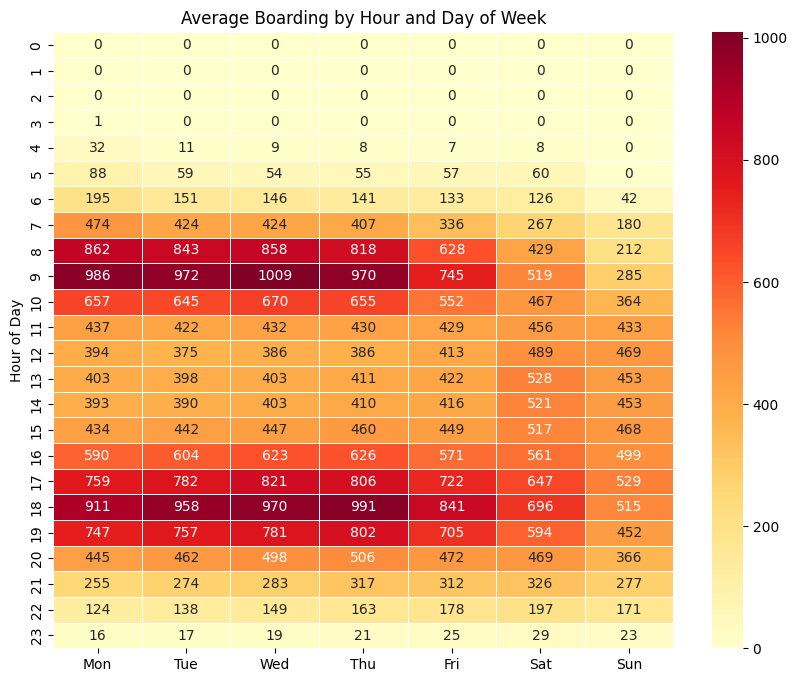

In [30]:
heatmap_data = df.pivot_table(values='Boarding_Count', index='Hour', columns='DayOfWeek', aggfunc='mean')
heatmap_data.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Average Boarding by Hour and Day of Week')
plt.ylabel('Hour of Day')
plt.show()

The heatmap clearly shows:
- Mon-Fri 8-9 AM and 6-7 PM are the hottest zones (darkest red)
- Saturday has moderate traffic, Sunday is lightest
- Late night (0-4 AM) is almost zero across all days

## Station Deep Dive — Busiest Station

In [31]:
busiest = station_totals.index[0]
print(f"Busiest station: {busiest}")

Busiest station: Nadaprabhu Kempegowda Station, Majestic


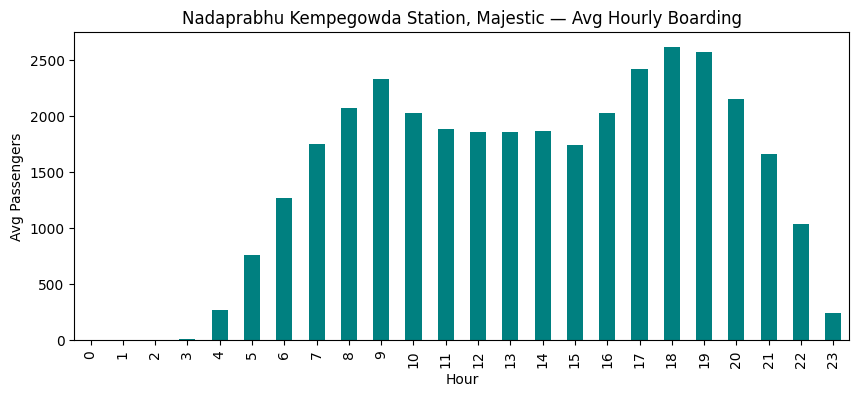

In [32]:
st_data = df[df['Station'] == busiest]
st_hourly = st_data.groupby('Hour')['Boarding_Count'].mean()

plt.figure(figsize=(10, 4))
st_hourly.plot(kind='bar', color='teal')
plt.title(f'{busiest} — Avg Hourly Boarding')
plt.xlabel('Hour')
plt.ylabel('Avg Passengers')
plt.show()

## Daily Total Trend

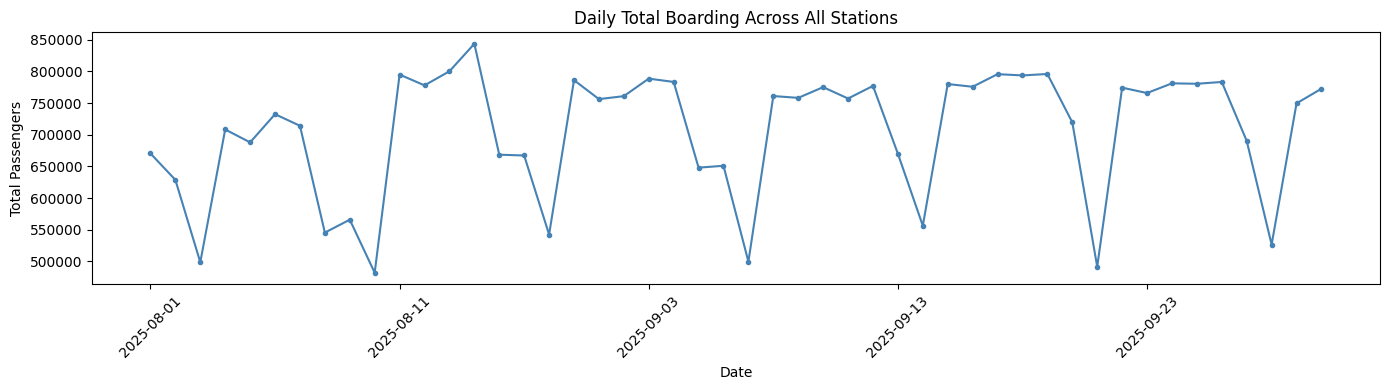

In [33]:
daily_total = df.groupby('Date')['Boarding_Count'].sum()

plt.figure(figsize=(14, 4))
daily_total.plot(kind='line', marker='.', color='steelblue')
plt.title('Daily Total Boarding Across All Stations')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can see weekly oscillation — dips every weekend. Also some dips that could be holidays.  
Notice the gap between Aug 18 and Sep 1 — the dataset doesnt cover Aug 19-31.

## Outlier Check

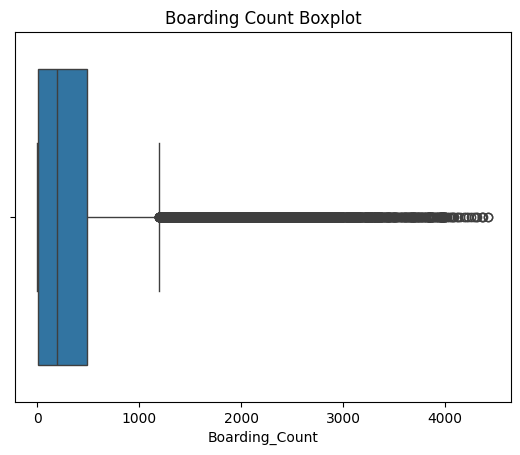

In [34]:
sns.boxplot(x=df['Boarding_Count'])
plt.title('Boarding Count Boxplot')
plt.show()

In [35]:
Q1 = df['Boarding_Count'].quantile(0.25)
Q3 = df['Boarding_Count'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 5.0, Q3: 482.0, IQR: 477.0


In [36]:
upper = Q3 + 1.5 * IQR
outliers = df[df['Boarding_Count'] > upper]
print(f"Outlier rows: {outliers.shape[0]} ({outliers.shape[0]/len(df)*100:.1f}%)")

Outlier rows: 5774 (6.0%)


In [37]:
# which stations are producing outliers?
outliers.groupby('Station')['Boarding_Count'].max().sort_values(ascending=False).head(10)

Station
Benniganahalli                                4425
Trinity                                       4421
Mahatma Gandhi Road                           4372
Nadaprabhu Kempegowda Station, Majestic       4365
Cubbon Park                                   3975
Indiranagar                                   3871
Dr. B. R. Ambedkar Station, Vidhana Soudha    3632
Sir M. Visvesvaraya Stn., Central College     3495
Chickpete                                     3360
Baiyappanahalli                               3327
Name: Boarding_Count, dtype: int32

In [38]:
# what hours do outliers fall in?
outliers['Hour'].value_counts().sort_index()

Hour
4       1
5      11
6      25
7     122
8     638
9     795
10    357
11    150
12    117
13    101
14    125
15    189
16    535
17    732
18    845
19    624
20    285
21     91
22     31
Name: count, dtype: int64

###  Outlier Analysis & Engineering Decision: Why We Do NOT Drop Outliers
The IQR calculation flags ~6% of rows as statistical outliers. In urban transit forecasting:
1. **Real Commuter Signals (Not Noise):** These values represent actual commuter surges during morning (8–10 AM) and evening (5–8 PM) rush hours at high-traffic interchange hubs (e.g., Majestic, Indiranagar).
2. **Preserving Timeline Continuity:** In time-series forecasting, deleting rows creates gaps in the hourly timeline, which corrupts subsequent lag features (`Lag_1h`, `Lag_24h`) and rolling window statistics.
3. **Core Project Objective:** The primary operational value of this forecasting system is accurately anticipating rush hour loads. Dropping high-traffic rows would force the model to systematically underestimate peak demand.